In [1]:
import os
work_dir = os.path.abspath('../../..')
print(work_dir)
os.chdir(work_dir)
import numpy as np
import sympy as sp
from scipy.integrate import odeint
from aiphy.experiment import default_parastructure, ExpConfig, Objstructure, DoExpType, ExpStructure
from aiphy.experiment import concept_posx, concept_posy, concept_posz, concept_t, concept_length

/home/lixiang/code/ai-physicist-base/ai-physicist


In [2]:
pi = 3.1415926
exp_para = {
    "l": default_parastructure(5.0, 7.0),
    "theta0": default_parastructure(0.0, 2*pi),
    "omega0": default_parastructure(pi/4.0, pi/2.0),
    "y0": default_parastructure(3.0, 5.0),
    "vx0": default_parastructure(1.0, 2.0),
    "vy0": default_parastructure(1.0, 2.0),
    "t0": default_parastructure(0.5, 1.5)
}

obj_info = {
    "o1": Objstructure.make_particle(1, 2),
    "o2": Objstructure.make_particle(2, 4),
    "clock": Objstructure.clock()
}
data_info = [
    (concept_posx, ["o1"]),
    (concept_posy, ["o1"]),
    (concept_posz, ["o1"]),
    (concept_posx, ["o2"]),
    (concept_posy, ["o2"]),
    (concept_posz, ["o2"]),
    (concept_t, ["clock"]),
]

In [3]:
exp_config = ExpConfig("collision_circle", 2, exp_para, obj_info, data_info)
exp_config.random_settings()

In [4]:
t_end=2.0
t_num=100
step = t_end / t_num
t = np.arange(0, t_end, step)
l = exp_config.para('l')
theta0 = exp_config.para('theta0')
omega0 = exp_config.para('omega0')
y0 = exp_config.para('y0')
vx0 = exp_config.para('vx0')
vy0 = exp_config.para('vy0')
t0 = exp_config.para('t0')
m1 = exp_config.get_obj_para("o1", "m")
m2 = exp_config.get_obj_para("o2", "m")
step = t_end / t_num
t = np.arange(0, t_end, step)

# after collison:
vx = (m2 * vx0 * y0**2 - l**2 * m1 * (vx0 + 2*omega0 * y0))/(l**2 * m1 + m2 * y0**2)
omega = (l**2 * m1 * omega0 - m2 * y0 * (2 * vx0 + omega0 * y0))/(l**2 * m1 + m2 * y0**2)

# motion trajectory
data_x = np.array([vx0*(i-t0) if i < t0 else vx*(i-t0) for i in t])
data_y = np.array([y0 + vy0*(i-t0) for i in t])
data_theta = np.array([theta0+pi/2 + omega0*(i-t0) if i < t0 else theta0+pi/2 + omega*(i-t0) for i in t])

data_x_ = np.cos(theta0) * data_x - np.sin(theta0) * data_y
data_y_ = np.sin(theta0) * data_x + np.cos(theta0) * data_y

In [5]:
import matplotlib.pyplot as plt

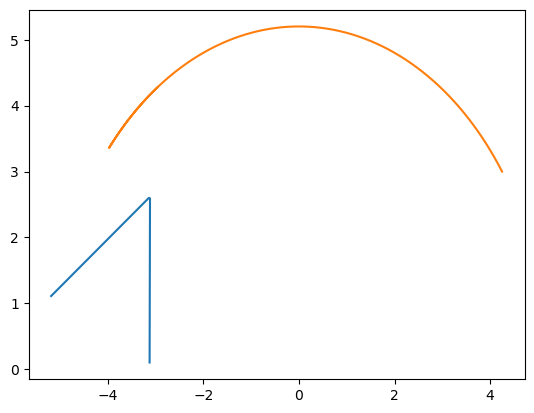

In [6]:
plt.plot(data_x_, data_y_)
plt.plot(l*np.cos(data_theta), l*np.sin(data_theta))

In [3]:
newset = {1, 2, 3}
newset.add('3')
newset

{1, 2, 3, '3'}

In [8]:
from tqdm import tqdm

In [9]:
name_list = [1, 2, 3, 4, 5]
for i, j in enumerate(tqdm(name_list, desc='Reduce Conclusions')):
    print((i, j))

Reduce Conclusions: 100%|██████████| 5/5 [00:00<00:00, 21098.11it/s]

(0, 1)
(1, 2)
(2, 3)
(3, 4)
(4, 5)
